In [5]:
import pandas as pd

# Load the Excel file
df = pd.read_excel('air_quality_data.xlsx')

# Display basic info to understand the data type and columns
print(df.info())

# Show first few rows to get a sense of data structure
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 2 columns):
 #   Column                            Non-Null Count  Dtype 
---  ------                            --------------  ----- 
 0   ã WHO 2022. All rights reserved.  15 non-null     object
 1   Unnamed: 1                        16 non-null     object
dtypes: object(2)
memory usage: 532.0+ bytes
None
  ã WHO 2022. All rights reserved.           Unnamed: 1
0                              NaN                  NaN
1                              NaN                  NaN
2                              NaN                  NaN
3                              NaN                  NaN
4                               v9  2022-07-21 00:00:00


In [9]:
import pandas as pd

# Load ONLY city-level air quality data
df = pd.read_excel("air_quality_data.xlsx", sheet_name="AAP_2022_city_v9")

# Quick look
print(df.head())
print(df.info())


                     WHO Region ISO3 WHO Country Name City or Locality  \
0  Eastern Mediterranean Region  AFG      Afghanistan            Kabul   
1               European Region  ALB          Albania           Durres   
2               European Region  ALB          Albania           Durres   
3               European Region  ALB          Albania          Elbasan   
4               European Region  ALB          Albania          Elbasan   

   Measurement Year  PM2.5 (μg/m3)  PM10 (μg/m3)  NO2 (μg/m3)  \
0              2019         119.77           NaN          NaN   
1              2015            NaN         17.65        26.63   
2              2016          14.32         24.56        24.78   
3              2015            NaN           NaN        23.96   
4              2016            NaN           NaN        26.26   

   PM25 temporal coverage (%)  PM10 temporal coverage (%)  \
0                        18.0                         NaN   
1                         NaN             

In [10]:
# Keep relevant columns
df = df[['WHO Country Name', 'City or Locality', 'Measurement Year',
         'PM2.5 (μg/m3)', 'PM10 (μg/m3)', 'NO2 (μg/m3)']]

# Drop rows where PM2.5 is missing
df = df.dropna(subset=['PM2.5 (μg/m3)'])


In [12]:
# Fill missing PM10 and NO2 with median values
df['PM10 (μg/m3)'] = df['PM10 (μg/m3)'].fillna(df['PM10 (μg/m3)'].median())
df['NO2 (μg/m3)']  = df['NO2 (μg/m3)'].fillna(df['NO2 (μg/m3)'].median())


In [13]:
from sklearn.preprocessing import LabelEncoder

le_country = LabelEncoder()
df['Country_Code'] = le_country.fit_transform(df['WHO Country Name'])

le_city = LabelEncoder()
df['City_Code'] = le_city.fit_transform(df['City or Locality'])


In [14]:
X = df[['Country_Code', 'City_Code', 'Measurement Year',
        'PM10 (μg/m3)', 'NO2 (μg/m3)']]
y = df['PM2.5 (μg/m3)']


In [15]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train model
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R² Score:", r2_score(y_test, y_pred))


MAE: 4.958742565522333
RMSE: 9.276989455253096
R² Score: 0.74521060182509


In [ ]:
#Visualizations

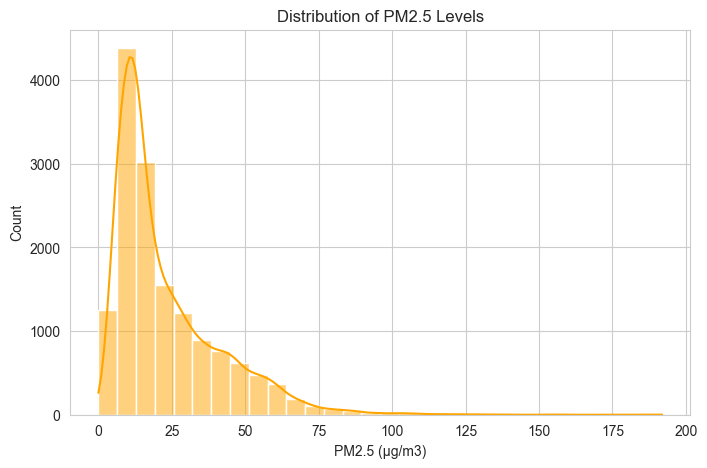

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

# Distribution of PM2.5
plt.figure(figsize=(8,5))
sns.histplot(df['PM2.5 (μg/m3)'], bins=30, kde=True, color='orange')
plt.title('Distribution of PM2.5 Levels')
plt.xlabel('PM2.5 (μg/m3)')
plt.show()




C:\Users\LENOVO\AppData\Local\Temp\ipykernel_8412\2658169630.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.index, y=top_countries.values, palette='Reds_r')


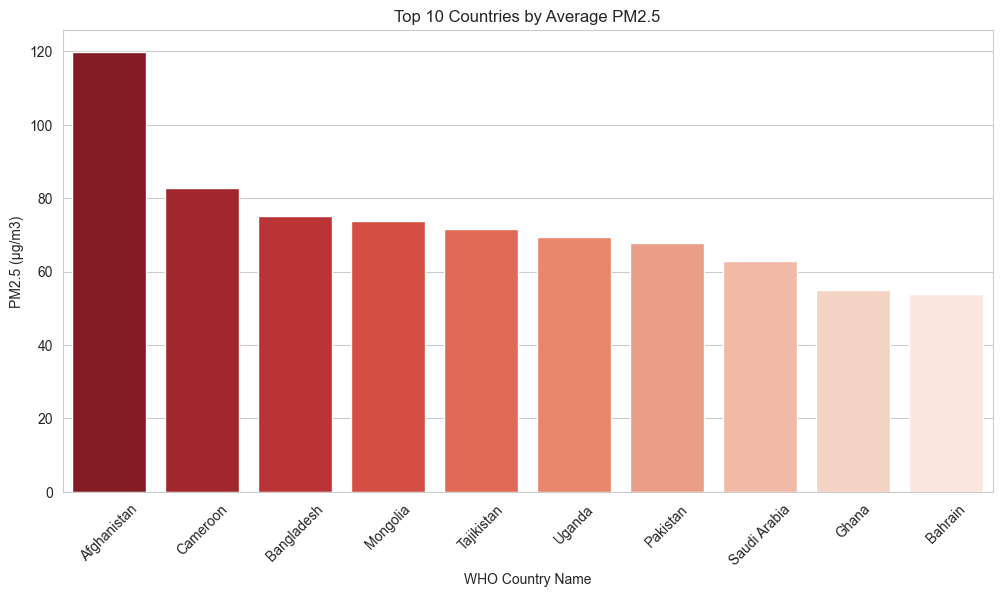

In [17]:
# Top 10 countries by average PM2.5
plt.figure(figsize=(12,6))
top_countries = df.groupby('WHO Country Name')['PM2.5 (μg/m3)'].mean().nlargest(10)
sns.barplot(x=top_countries.index, y=top_countries.values, palette='Reds_r')
plt.xticks(rotation=45)
plt.title('Top 10 Countries by Average PM2.5')
plt.ylabel('PM2.5 (μg/m3)')
plt.show()


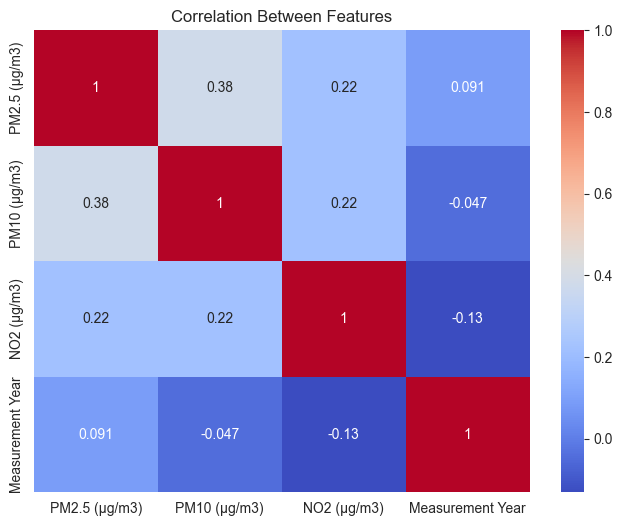

In [18]:
# Correlation Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df[['PM2.5 (μg/m3)','PM10 (μg/m3)','NO2 (μg/m3)','Measurement Year']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Between Features')
plt.show()


In [20]:
from sklearn.model_selection import RandomizedSearchCV

# Hyperparameter search space
param_grid = {
    'n_estimators': [100, 200, 300, 500, 800, 1000],
    'max_depth': [None, 10, 20, 30, 40, 50],
    'max_features': ['auto', 'sqrt'],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf = RandomForestRegressor(random_state=42)

rf_random = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_grid,
    n_iter=30,
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1,
    scoring='neg_mean_squared_error'
)

rf_random.fit(X_train, y_train)

print("Best Parameters:", rf_random.best_params_)

# Evaluate tuned model
best_model = rf_random.best_estimator_
y_pred_tuned = best_model.predict(X_test)

print("Tuned MAE:", mean_absolute_error(y_test, y_pred_tuned))
print("Tuned RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_tuned)))
print("Tuned R²:", r2_score(y_test, y_pred_tuned))


Fitting 5 folds for each of 30 candidates, totalling 150 fits


C:\Users\LENOVO\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
70 fits failed out of a total of 150.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
35 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\LENOVO\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\LENOVO\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py", line 1382, in wrapper
    estimator._validate_params()
  File "C:\Users\LENOVO\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\ba

Best Parameters: {'n_estimators': 800, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 20}
Tuned MAE: 5.215101004202433
Tuned RMSE: 9.599518399151833
Tuned R²: 0.7271863363787746


In [ ]:
#Actual VS Predicted

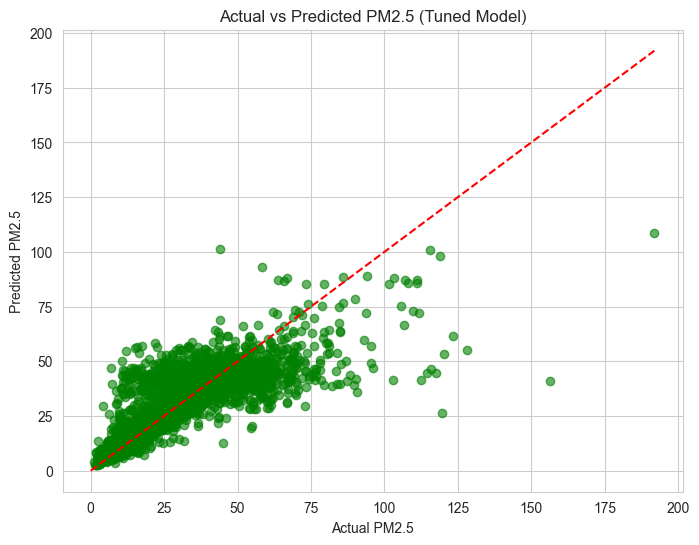

In [21]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_tuned, alpha=0.6, color='green')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel("Actual PM2.5")
plt.ylabel("Predicted PM2.5")
plt.title("Actual vs Predicted PM2.5 (Tuned Model)")
plt.show()


In [22]:
import pickle
with open('pm25_prediction_model.pkl', 'wb') as file:
    pickle.dump(best_model, file)
